MARIAN MODEL

In [1]:
import os, random, numpy as np, torch, inspect
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
import matplotlib.pyplot as plt

# for reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True

# Project & run knobs (kept small/fast)
PROJECT_DIR = "./marian_bilingual_en_es_pt"
os.makedirs(PROJECT_DIR, exist_ok=True)

MAX_SAMPLES = 1200        # per split, per language direction (train subset)
EVAL_SAMPLES = 300        # validation slice for quick BLEU
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128
BATCH = 8                 # lower to 4/2 if OOM
GRAD_ACCUM = 1
MAX_STEPS = 500          # short fine-tune; bump to 1500+ for quality

device = "cuda" if torch.cuda.is_available() else "cpu" 
#16-bit floating-point formats  
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)() #fp 16 has more range but less precision than bf16
use_fp16 = torch.cuda.is_available() and not use_bf16 #use fp16 if bf16 not supported
print(f"Device={device} | bf16={use_bf16} | fp16={use_fp16}") #bf16 preferred when available




Device=cuda | bf16=True | fp16=False


c:\Users\jeeva\anaconda3\Lib\site-packages\torch\__init__.py:1628: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:50.)
  _C._set_float32_matmul_precision(precision)


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("CUDA runtime version in wheel:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

PyTorch: 2.10.0.dev20251030+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
CUDA runtime version in wheel: 12.8
cuDNN version: 91002


In [3]:
# --- EN→ES (Marian) ---
tok_es = AutoTokenizer.from_pretrained( #   EN→ES (Marian)
    "Helsinki-NLP/opus-mt-en-es", #from hugging face library 
    token=None,               # force anonymous (ignore any stale tokens)
    local_files_only=False,   # allow fresh download if not cached
    use_fast=True
)
mod_es = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es", #  EN→ES (Marian)
    token=None,
    local_files_only=False
).to(device)

# --- EN→PT (Marian ONLY; no fallback) 

# EN→PT (Marian) 

tok_pt = AutoTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",  
    token=None,
    local_files_only=False,
    use_fast=True
)
mod_pt = AutoModelForSeq2SeqLM.from_pretrained(
    "Helsinki-NLP/opus-mt-tc-big-en-pt",
    token=None,
    local_files_only=False
).to(device)

assert getattr(mod_pt.config, "model_type", "") == "marian", \
    f"Unexpected PT model type: {getattr(mod_pt.config, 'model_type', '?')}"
print("✅ Loaded EN→PT (Marian) from mirror")



✅ Loaded EN→PT (Marian) from mirror


In [28]:
GLOSSARY = {
    "polymerase chain reaction": {"es": "reacción en cadena de la polimerasa", "pt": "reação em cadeia da polimerase"},
    "confidence interval": {"es": "intervalo de confianza", "pt": "intervalo de confiança"},
}
def apply_glossary(text: str, lang: str) -> str:
    out = text
    for en_term, mapping in GLOSSARY.items():
        if lang in mapping:
            out = out.replace(en_term, mapping[lang])
    return out


# === TMX loader for EN↔ES / EN↔PT ===
import os, re, xml.etree.ElementTree as ET
from datasets import Dataset

# Point this at your TMX files.
# Option A: separate TMX files per split:
TMX_ROOT = (r"J:\FINAL PROJECT")    # ← change this

TMX_FILES = {
    "en-es": {
        "train":      os.path.join(TMX_ROOT, "data", "en-es.tmx"),
        "validation": None,   # force split path
    },
    "en-pt": {
        "train":      os.path.join(TMX_ROOT, "data", "en-pt.tmx"),
        "validation": None,   # force split path
    },
}


#global cleaning and deduplication for TMX data as well as splitting into train/validation for 1 file per pair

import re, random
from datasets import Dataset

def looks_fragment(x: str) -> bool:
    x = (x or "").strip()
    if not x: return True
    if x.endswith(":"): return True
    # short numeric/punct-only items
    return bool(re.fullmatch(r"[\(\)\[\]0-9.,;:/\-]{1,6}", x))

def langid(src, tgt, tgt_lang="es", use_langid=False):
  if use_langid:
        keep = [i for i,(s,t) in enumerate(zip(src,tgt))
                if langid.classify(s)[0] == "en" and langid.classify(t)[0] == tgt_lang]
        src = [src[i] for i in keep]; tgt = [tgt[i] for i in keep]

def read_tmx_all(path, src_key, tgt_key):
    # uses my existing _read_tmx_pairs()
    src_all, tgt_all = _read_tmx_pairs(path, src_key, tgt_key, max_samples=None)
    return src_all, tgt_all

def global_clean_and_dedup(src_all, tgt_all, min_ratio=0.5, max_ratio=2.0):
    TAG = re.compile(r"</?[^>]+>")
    WS  = re.compile(r"\s+")
    def norm(x): return WS.sub(" ", TAG.sub(" ", x or "")).strip()

    rows = []
    for s, t in zip(src_all, tgt_all):
        s2, t2 = norm(s), norm(t)
        if not s2 or not t2:
            continue
        r = len(t2) / max(1, len(s2))
        if r < min_ratio or r > max_ratio:
            continue
        rows.append((s2, t2))

    # Dedup by SOURCE so the same EN cannot land in both splits
    seen_src = set()
    uniq = []
    for s2, t2 in rows:
        if s2 in seen_src:
            continue
        seen_src.add(s2)
        uniq.append((s2, t2))

    src_clean = [s for s, _ in uniq]
    tgt_clean = [t for _, t in uniq]
    return src_clean, tgt_clean

def split_to_datasets(src_clean, tgt_clean, split_ratio=0.9, seed=42,
                      max_train=None, max_valid=None):
    idxs = list(range(len(src_clean)))
    rng = random.Random(seed); rng.shuffle(idxs)
    cut = int(len(idxs) * split_ratio)
    train_idx, valid_idx = idxs[:cut], idxs[cut:]

    if max_train is not None:
        train_idx = train_idx[:max_train]
    if max_valid is not None:
        valid_idx = valid_idx[:max_valid]

    def build(idxs):
        return Dataset.from_dict({
            "src_text": [src_clean[i] for i in idxs],
            "tgt_text": [tgt_clean[i] for i in idxs],
        })
    return build(train_idx), build(valid_idx)

def report_overlap(train_ds, valid_ds, name):
    tsrc = set(train_ds["src_text"]); vsrc = set(valid_ds["src_text"])
    tp   = set(zip(train_ds["src_text"], train_ds["tgt_text"]))
    vp   = set(zip(valid_ds["src_text"], valid_ds["tgt_text"]))
    print(f"[{name}] src overlap={len(tsrc & vsrc)} pair overlap={len(tp & vp)}")


#  have ONE TMX per pair, set the same path for both keys above
# and use SPLIT_RATIO to slice it deterministically
SPLIT_RATIO = 0.9  # 90% train / 10% validation (used only if one file per pair)

# Accept common lang codes seen in TMX (case-insensitive)
_LANG_ALIASES = {
    "en": {"en", "eng", "en-us", "en-gb"},
    "es": {"es", "spa", "es-es", "es-la", "es-mx"},
    "pt": {"pt", "por", "pt-pt", "pt-br"},
}
def _norm_lang(code: str) -> str:
    c = (code or "").lower()
    for k, aliases in _LANG_ALIASES.items():
        if c in aliases:
            return k
    # try collapse region codes like xx-YY
    m = re.match(r"^([a-z]{2})[-_][a-z]{2}$", c)
    if m and m.group(1) in _LANG_ALIASES:
        return m.group(1)
    return c  # fallback

def _extract_pair_from_tu(tu_elem, src_key, tgt_key):
    """
    From a <tu> that contains multiple <tuv xml:lang=...><seg>...</seg>,
    return (src_text, tgt_text) if both languages present; else None.
    """
    texts = {}
    for tuv in tu_elem.findall(".//tuv"):
        lang = _norm_lang(tuv.attrib.get("{http://www.w3.org/XML/1998/namespace}lang") or
                          tuv.attrib.get("lang") or "")
        seg = tuv.find(".//seg")
        if seg is not None and seg.text is not None:
            texts[lang] = seg.text.strip()
    if src_key in texts and tgt_key in texts:
        return texts[src_key], texts[tgt_key]
    return None

def _read_tmx_pairs(path, src_key, tgt_key, max_samples=None):
    """
    Parse TMX and return two aligned lists: src_texts, tgt_texts
    Only keeps TUs that have BOTH requested languages.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"TMX not found: {path}")
    # ET.iterparse keeps memory moderate
    src, tgt = [], []
    # TMX is typically utf-8, but some legacy files differ; change encoding if needed.
    for event, elem in ET.iterparse(path, events=("end",)):
        if elem.tag.lower().endswith("tu"):  # match 'tu' with namespace or not
            pair = _extract_pair_from_tu(elem, src_key, tgt_key)
            if pair:
                s, t = pair
                if s and t:
                    src.append(s)
                    tgt.append(t)
                    if max_samples and len(src) >= max_samples:
                        break
            elem.clear()  # free memory
    return src, tgt

def load_tmx_dataset(pair: str, split: str, max_samples: int,
                     files_map=TMX_FILES, split_ratio=SPLIT_RATIO, seed=42):
    """
    pair: 'en-es' or 'en-pt'
    split: 'train' or 'validation' (also accepts 'valid', 'dev')
    returns HF Dataset with columns: src_text, tgt_text
    """
    split = {"dev": "validation", "valid": "validation"}.get(split, split)
    assert pair in ("en-es", "en-pt"), f"Unsupported pair: {pair}"
    src_key, tgt_key = pair.split("-")

    # Which TMX path to use?
    tmx_map = files_map.get(pair, {})
    path = tmx_map.get(split)

    if path and os.path.exists(path):
        # Direct TMX file per split
        src, tgt = _read_tmx_pairs(path, src_key, tgt_key, max_samples=max_samples)
        return Dataset.from_dict({"src_text": src, "tgt_text": tgt})
    else:
        # Single TMX for the pair? Try 'train' entry (or any that exists) and split in-memory.
        # Find any existing file for this pair:
        candidates = [p for p in tmx_map.values() if p and os.path.exists(p)]
        if not candidates:
            # As a fallback, try a conventional name in TMX_ROOT
            guess = os.path.join(TMX_ROOT, f"scielo_{pair.replace('-','_')}.tmx")
            if os.path.exists(guess):
                candidates = [guess]
        if not candidates:
            raise FileNotFoundError(f"No TMX file found for {pair}. Checked: {tmx_map} and {TMX_ROOT}")

        mono_path = candidates[0]
        # Load ALL (bounded by max_samples * 2 just to ensure enough for split)
        cap = None if max_samples is None else int(max_samples / max(1e-9, (1.0 if split == "train" else (1.0 - split_ratio)))) + 5
        src_all, tgt_all = _read_tmx_pairs(mono_path, src_key, tgt_key, max_samples=cap)

        # Deterministic split
        import random
        rnd_idx = list(range(len(src_all)))
        rng = random.Random(seed)
        rng.shuffle(rnd_idx)

        cut = int(len(rnd_idx) * split_ratio)
        idxs = rnd_idx[:cut] if split == "train" else rnd_idx[cut:]
        if max_samples: idxs = idxs[:max_samples]

        src = [src_all[i] for i in idxs]
        tgt = [tgt_all[i] for i in idxs]
        return Dataset.from_dict({"src_text": src, "tgt_text": tgt})


In [29]:

es_path = TMX_FILES["en-es"]["train"]   # use only ONE path
print("ES TMX:", os.path.abspath(es_path))
src_es_all, tgt_es_all   = read_tmx_all(es_path, "en", "es")
src_es_clean, tgt_es_clean = global_clean_and_dedup(src_es_all, tgt_es_all)
train_es, valid_es = split_to_datasets(src_es_clean, tgt_es_clean,
                                       split_ratio=SPLIT_RATIO, seed=SEED,
                                       max_train=MAX_SAMPLES, max_valid=EVAL_SAMPLES)

# Build PT datasets from ONE TMX (train path); validation will be split from it 
pt_path = TMX_FILES["en-pt"]["train"]
print("PT TMX:", os.path.abspath(pt_path))
src_pt_all, tgt_pt_all   = read_tmx_all(pt_path, "en", "pt")
src_pt_clean, tgt_pt_clean = global_clean_and_dedup(src_pt_all, tgt_pt_all)
train_pt, valid_pt = split_to_datasets(src_pt_clean, tgt_pt_clean,
                                       split_ratio=SPLIT_RATIO, seed=SEED,
                                       max_train=MAX_SAMPLES, max_valid=EVAL_SAMPLES)

# (must be 0 / 0)
report_overlap(train_es, valid_es, "EN→ES")
report_overlap(train_pt, valid_pt, "EN→PT")

# Hard assertions 
assert len(set(train_es["src_text"]) & set(valid_es["src_text"])) == 0, "ES src overlap!"
assert len(set(zip(train_es["src_text"], train_es["tgt_text"])) &
           set(zip(valid_es["src_text"], valid_es["tgt_text"]))) == 0, "ES pair overlap!"
assert len(set(train_pt["src_text"]) & set(valid_pt["src_text"])) == 0, "PT src overlap!"
assert len(set(zip(train_pt["src_text"], train_pt["tgt_text"])) &
           set(zip(valid_pt["src_text"], valid_pt["tgt_text"]))) == 0, "PT pair overlap!"


ES TMX: J:\FINAL PROJECT\data\en-es.tmx
PT TMX: J:\FINAL PROJECT\data\en-pt.tmx
[EN→ES] src overlap=0 pair overlap=0
[EN→PT] src overlap=0 pair overlap=0


In [6]:
# # === Use TMX datasets ===
# train_es = load_tmx_dataset("en-es", "train", MAX_SAMPLES)
# valid_es = load_tmx_dataset("en-es", "validation", EVAL_SAMPLES)

# train_pt = load_tmx_dataset("en-pt", "train", MAX_SAMPLES)
# valid_pt = load_tmx_dataset("en-pt", "validation", EVAL_SAMPLES)

# print("Train sizes  EN→ES / EN→PT:", len(train_es), len(train_pt))
# print("Valid sizes  EN→ES / EN→PT:", len(valid_es), len(valid_pt))


In [7]:
# ## **CELL — Light cleaning (empties, extreme length ratio, HTML-ish tags, duplicates)**

# # Simple HTML/markup stripper (keeps the text inside tags, removes the tags)


# clean=False

# _TAG_RE = re.compile(r"</?[^>]+>")
# _WS_RE  = re.compile(r"\s+")

# def _norm_text(x: str) -> str:
#     if x is None:
#         return ""
#     # remove basic HTML/XML tags
#     x = _TAG_RE.sub(" ", x)
#     # normalize whitespace
#     x = _WS_RE.sub(" ", x).strip()
#     return x

# def lightly_clean(ds, src_col="src_text", tgt_col="tgt_text",
#                   min_ratio=0.5, max_ratio=2.0):
#     """
#     - drops empty rows
#     - drops extreme length-mismatch pairs
#     - removes duplicate (src,tgt) pairs
#     - strips basic HTML/XML tags & normalizes whitespace
#     """
#     seen = set()
#     keep_src, keep_tgt = [], []

#     src_list = ds[src_col]
#     tgt_list = ds[tgt_col]

#     for s, t in zip(src_list, tgt_list):
#         s2, t2 = _norm_text(s), _norm_text(t)
#         if not s2 or not t2:
#             continue

#         # length ratio filter
#         r = len(t2) / max(1, len(s2))
#         if r < min_ratio or r > max_ratio:
#             continue

#         key = (s2, t2)
#         if key in seen:
#             continue
#         seen.add(key)

#         keep_src.append(s2)
#         keep_tgt.append(t2)

#     if not keep_src:
#         raise ValueError("After cleaning, no examples left—loosen filters.")

#     return Dataset.from_dict({src_col: keep_src, tgt_col: keep_tgt})


# # Light cleaning
# train_es = lightly_clean(train_es)
# valid_es = lightly_clean(valid_es)
# train_pt = lightly_clean(train_pt)
# valid_pt = lightly_clean(valid_pt)


# print("After cleaning:",
#       len(train_es), len(valid_es), len(train_pt), len(valid_pt))


In [8]:
# def clean_ratio(ds, lo=0.6, hi=1.6, min_words=5):
#     keep = []
#     for i, ex in enumerate(ds):
#         s = len(ex["src_text"].split())
#         t = len(ex["tgt_text"].split())
#         if t == 0:
#             continue
#         r = s / t
#         if lo <= r <= hi and s >= min_words and t >= min_words:
#             keep.append(i)
#     return ds.select(keep)

# print("Before cleaning:", len(train_pt), len(valid_pt))
# train_pt = clean_ratio(train_pt)
# valid_pt = clean_ratio(valid_pt)
# print("After cleaning:", len(train_pt), len(valid_pt))


In [9]:
import random, re, pandas as pd
import matplotlib.pyplot as plt

def show_random_pairs(ds, n=10, seed=42):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    for i in idxs:
        print(f"\n=== SAMPLE {i} ===")
        print("SRC:", ds[i]["src_text"])
        print("TGT:", ds[i]["tgt_text"])

def show_table(ds, start=0, count=15):
    end = min(start + count, len(ds))
    df = pd.DataFrame({
        "EN (src)": [ds[i]["src_text"] for i in range(start, end)],
        "XX (tgt)": [ds[i]["tgt_text"] for i in range(start, end)],
        "idx": list(range(start, end)),
    })
    df = df[["idx","EN (src)","XX (tgt)"]]
    display(df)

def inspect(ds, start=0, count=20):
    for i in range(start, min(start + count, len(ds))):
        print(f"\n[{i}]")
        print("EN:", ds[i]["src_text"])
        print("XX:", ds[i]["tgt_text"])

_num_re = re.compile(r"\d+(?:[.,]\d+)?%?")

def highlight_numbers(ds, idx):
    s, t = ds[idx]["src_text"], ds[idx]["tgt_text"]
    print(f"\n[{idx}]")
    print("EN:", s)
    print("XX:", t)
    print("EN nums:", _num_re.findall(s), " | XX nums:", _num_re.findall(t))

def plot_length_ratios(ds, title="Length ratios (src/tgt)"):
    ratios = []
    for ex in ds:
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t > 0:
            ratios.append(s/t)
    plt.figure()
    plt.hist(ratios, bins=50)
    plt.title(title)
    plt.xlabel("src_words / tgt_words")
    plt.ylabel("count")
    plt.show()
    return ratios

def show_worst_by_ratio(ds, top=20):
    ratios = []
    for i, ex in enumerate(ds):
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t > 0:
            ratios.append((i, abs((s/t) - 1.0)))
    ratios.sort(key=lambda x: x[1], reverse=True)
    for i, _ in ratios[:top]:
        inspect(ds, start=i, count=1)


🔎 EN→ES random pairs:

=== SAMPLE 228 ===
SRC: In our study, age group was not a statistically significant factor in the presence of cognitive-affective or somatic symptoms.
TGT: En nuestro estudio, el rango de edad no fue un factor estadísticamente significativo en la presencia de síntomas cognitivo-afectivos o somáticos.

=== SAMPLE 51 ===
SRC: Places falling within this category are useful for the establishment of shelters as opposed to exposed landscapes, which are intended for the collection of materials. As for women, dimension 1 refers to “the Complexity of Land” or the number and distribution of elements.
TGT: En el caso de las mujeres, la dimensión 1 es la ‘Complejidad del Suelo’, o la cantidad y distribución de elementos en el plano, sin embargo, a diferencia de los hombres, en este caso los lugares con obstáculos determinan si el paisaje tiene utilidad, o no para la emergencia.

=== SAMPLE 563 ===
SRC: The categorization of the units of stories presupposes a view of the obje

,idx,EN (src),XX (tgt)
0,0,"Nonetheless, it should be considered that only...","Es necesario considerar, sin embargo, que apen..."
1,1,"For the second indicator, 3% of households rep...","En el segundo indicador, el 3% de los hogares ..."
2,2,"Regarding the occupational issue, the return t...","En cuanto a la cuestión ocupacional, el retorn..."
3,3,"Therefore, multivariate analysis had to be use...","Siendo así, es obligatorio el análisis multiva..."
4,4,"Ph Dc., In Agronomy Soil Science, FCAV/ UNESP,...","Ph Dc., en Agronomía Ciencia del Suelo, FCAV/ ..."
5,5,"Finally, it is considered that nursing work is...","Para finalizar, se pondera que el trabajo de e..."
6,6,"The hands of other people, especially if they ...",Las manos de otras personas sobre todo si tien...
7,7,All participants were conducted to the data co...,Todas las participantes fueron conducidas a la...
8,8,"For data source, we used the electronic record...","Para fuente de datos, se utilizó el prontuario..."
9,9,The first International Conference on Primary ...,En septiembre de 1978 fue realizada la primera...



📈 EN→ES length ratios (train):


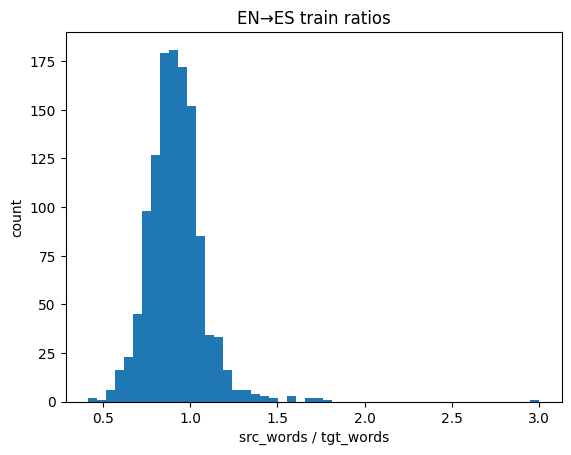


🚩 EN→ES worst by ratio (top 10):

[246]
EN: * Please cite this article as: Páez L. JJ, Navarro V. JR.
XX: * Autor para correspondencia.

[407]
EN: The inconsistent items, 12 and 21, were "How often do you have to explain to others what it means to have diabetes" 0.1910 and "How often do you think that your parents protect you a lot" 0.1959.
XX: Los ítems inconsistentes 12 y 21 fueron: "¿Con qué frecuencia tiene que explicar a los otros lo que es tener diabetes?"0.1959.

[38]
EN: He shared the same experience with me.
XX: Compartía conmigo lo mismo.

[255]
EN: There s no way, you can t manage to be completely impartial.
XX: Ser una persona neutra no es posible.

[166]
EN: The very best to all.
XX: Felicitaciones a todos.

[759]
EN: Most PUs 68.4% were in stage II; stage III and IV PUs were not found.
XX: No fueron encontradas úlceras en nivel III y IV.

[492]
EN: Hospital universitario de Cartagena University Hospital of Cartagena Cartagena, Colombia.
XX: Se presenta el caso de un adul

In [10]:
print("🔎 EN→ES random pairs:")
show_random_pairs(train_es, n=8)

print("\n📋 EN→ES table view (first 15):")
show_table(train_es, start=0, count=15)

print("\n📈 EN→ES length ratios (train):")
_ = plot_length_ratios(train_es, title="EN→ES train ratios")

print("\n🚩 EN→ES worst by ratio (top 10):")
show_worst_by_ratio(train_es, top=10)

# (optional) check numbers on any suspicious index
# highlight_numbers(train_es, idx=123)


In [11]:
def preprocess_any(batch, tok, tgt_short: str):
    
    targets = [apply_glossary(t, tgt_short) for t in batch["tgt_text"]]

    # Encode source (Marian: no src/tgt lang flags needed)
    model_inputs = tok(
        batch["src_text"],
        truncation=True,
        max_length=MAX_SRC_LEN,
    )

    # Encode labels (HF>=4.27 supports text_target; keep fallback for older versions)
    try:
        labels = tok(
            text_target=targets,
            truncation=True,
            max_length=MAX_TGT_LEN,
        )
    except TypeError:
        from contextlib import contextmanager
        cm = tok.as_target_tokenizer() if hasattr(tok, "as_target_tokenizer") else contextmanager(lambda: (yield))()
        with cm:
            labels = tok(
                targets,
                truncation=True,
                max_length=MAX_TGT_LEN,
            )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Rebuild tokenized datasets
train_es_tok = train_es.map(lambda b: preprocess_any(b, tok_es, "es"),
                            batched=True, remove_columns=train_es.column_names)
valid_es_tok = valid_es.map(lambda b: preprocess_any(b, tok_es, "es"),
                            batched=True, remove_columns=valid_es.column_names)

train_pt_tok = train_pt.map(lambda b: preprocess_any(b, tok_pt, "pt"),
                            batched=True, remove_columns=train_pt.column_names)
valid_pt_tok = valid_pt.map(lambda b: preprocess_any(b, tok_pt, "pt"),
                            batched=True, remove_columns=valid_pt.column_names)

print("✅ Tokenization done (ES & PT).")


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

✅ Tokenization done (ES & PT).


In [12]:
def report_overlap(train_ds, valid_ds, name):
    tsrc = set(train_ds["src_text"]); vsrc = set(valid_ds["src_text"])
    tp   = set(zip(train_ds["src_text"], train_ds["tgt_text"]))
    vp   = set(zip(valid_ds["src_text"], valid_ds["tgt_text"]))
    print(f"[{name}] src overlap={len(tsrc&vsrc)} pair overlap={len(tp&vp)}")
report_overlap(train_es, valid_es, "EN→ES")
report_overlap(train_pt, valid_pt, "EN→PT")


[EN→ES] src overlap=0 pair overlap=0
[EN→PT] src overlap=0 pair overlap=0


In [13]:
bleu = evaluate.load("sacrebleu")

def compute_metrics_for(tok):
    def _inner(eval_pred):
        preds, labels = eval_pred
        # decode preds
        decoded_preds = tok.batch_decode(preds, skip_special_tokens=True)
        # replace -100 in labels then decode
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        decoded_labels = tok.batch_decode(labels, skip_special_tokens=True)
        return {"bleu": bleu.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])["score"]}
    return _inner

def make_training_args(**wanted):
    # filter kwargs to support older transformers
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    dropped = sorted(set(wanted) - set(filtered))
    if dropped: print("Dropped unsupported keys:", dropped)
    return TrainingArguments(**filtered)


In [14]:
#  Self-healing EN→ES trainer 
import inspect, torch
from transformers import TrainingArguments, DataCollatorForSeq2Seq, Trainer


#  Build/rebuild collator
collator_es = DataCollatorForSeq2Seq(
    tokenizer=tok_es,
    model=mod_es,
    padding="longest",               # or pad_to_multiple_of=8 for GPU speed
)

#  Version-agnostic TrainingArguments 
def make_training_args(**wanted):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    return TrainingArguments(**filtered)

args_es = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_es",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=3e-5,
    lr_scheduler_type="linear",    # ignored if unsupported by your version
    warmup_ratio=0.05,             # ignored if unsupported
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,      # safe on Windows
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",      # ignored if unsupported
    save_strategy="no",            # ignored if unsupported
)

# Build trainer 
trainer_es = Trainer(
    model=mod_es,
    args=args_es,
    train_dataset=train_es_tok,
    eval_dataset=None,             # eval later in a separate cell
    data_collator=collator_es,
    tokenizer=tok_es,
)

print("✅ EN→ES trainer ready. Starting training…")
train_output = trainer_es.train()
print("✅ EN→ES done.")


C:\Users\jeeva\AppData\Local\Temp\ipykernel_23248\191591290.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_es = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✅ EN→ES trainer ready. Starting training…


Step,Training Loss
50,1.248800
100,1.383100
150,1.291900
200,1.029000
250,1.074700
300,1.089500
350,0.958200
400,0.888500
450,0.934400
500,0.906900


✅ EN→ES done.


In [15]:
# Self-healing EN→PT trainer
import inspect, torch
from transformers import TrainingArguments, DataCollatorForSeq2Seq, Trainer

#  Build/rebuild collator 
collator_pt = DataCollatorForSeq2Seq(
    tokenizer=tok_pt,
    model=mod_pt,
    padding="longest",               # or pad_to_multiple_of=8 for GPU speed
)



args_pt = make_training_args(
    output_dir=f"{PROJECT_DIR}/ckpt_pt",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=3e-5,
    lr_scheduler_type="linear",     
    warmup_ratio=0.05,               
    
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    bf16=use_bf16,
    fp16=use_fp16,
    no_cuda=(device != "cuda"),
    dataloader_num_workers=0,        # safe on Windows
    dataloader_pin_memory=(device == "cuda"),
    evaluation_strategy="no",        # ignored if unsupported
    save_strategy="no",              # ignored if unsupported
)

# ---- Build trainer ----
trainer_pt = Trainer(
    model=mod_pt,
    args=args_pt,
    train_dataset=train_pt_tok,
    eval_dataset=None,               # eval later in a separate cell
    data_collator=collator_pt,
    tokenizer=tok_pt,
)

print("✅ EN→PT trainer ready. Starting training…")
train_output_pt = trainer_pt.train()
print("✅ EN→PT done.")


C:\Users\jeeva\AppData\Local\Temp\ipykernel_23248\980591894.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_pt = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


✅ EN→PT trainer ready. Starting training…


Step,Training Loss
50,1.200900
100,1.132200
150,1.135600
200,0.847700
250,0.856400
300,0.864400
350,0.683900
400,0.685600
450,0.673200
500,0.597000


✅ EN→PT done.


In [23]:
import torch, numpy as np, evaluate

bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")
ter_metric  = evaluate.load("ter")  # <-- added

GEN_KW = dict(
    num_beams=5,
    max_new_tokens=128,
    min_new_tokens=5,
    length_penalty=1.1,
    no_repeat_ngram_size=3,
    do_sample=False,
    early_stopping=True,
    return_dict_in_generate=False,
)
#eval in chunks to avoid OOM
def eval_chunked(model, tok, valid_ds, name, max_len_src=256, batch_size=16):
    model.eval()
    if hasattr(model, "gradient_checkpointing") and getattr(model, "is_gradient_checkpointing", False):
        model.gradient_checkpointing_disable()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = True

    src  = [r["src_text"] for r in valid_ds]
    refs = [r["tgt_text"] for r in valid_ds]
    preds = []

    with torch.inference_mode():
        for i in range(0, len(src), batch_size):
            sl = slice(i, i+batch_size)
            enc = tok(
                src[sl],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_len_src,
                pad_to_multiple_of=8
            )
            enc = {k: v.to(model.device, non_blocking=True) for k, v in enc.items()}
            out_ids = model.generate(**enc, **GEN_KW)
            preds.extend(tok.batch_decode(out_ids, skip_special_tokens=True))
            del enc, out_ids
            torch.cuda.empty_cache()

    refs_bleu = [[r] for r in refs[:len(preds)]]

    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu, use_effective_order=True)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    ter  = ter_metric.compute(predictions=preds, references=refs_bleu)["score"]  # <-- added
    exact = float(np.mean([p == r for p, r in zip(preds, refs[:len(preds)])]) * 100.0)

    print(f"{name} on {len(preds)} examples → BLEU {bleu:.2f} | chrF {chrf:.2f} | TER {ter:.2f} | Exact {exact:.2f}%")
    return {"name": name, "bleu": bleu, "chrf": chrf, "ter": ter, "exact": exact}


In [24]:
res_es = eval_chunked(mod_es, tok_es, valid_es, "EN→ES", batch_size=16)
res_pt = eval_chunked(mod_pt, tok_pt, valid_pt, "EN→PT", batch_size=16)
print({"es": res_es, "pt": res_pt})


EN→ES on 300 examples → BLEU 40.91 | chrF 67.84 | TER 45.69 | Exact 0.33%
EN→PT on 300 examples → BLEU 40.66 | chrF 68.96 | TER 45.82 | Exact 1.67%
{'es': {'name': 'EN→ES', 'bleu': 40.914142244717034, 'chrf': 67.83869411570427, 'ter': 45.68507157464213, 'exact': 0.33333333333333337}, 'pt': {'name': 'EN→PT', 'bleu': 40.662029481505705, 'chrf': 68.95794489616682, 'ter': 45.81831290555155, 'exact': 1.6666666666666667}}


In [18]:
# import numpy as np, evaluate, torch

# bleu_metric = evaluate.load("sacrebleu")
# chrf_metric = evaluate.load("chrf")

# GEN_KW = dict(
#     num_beams=5,
#     max_new_tokens=128,
#     min_new_tokens=5,
#     length_penalty=1.1,
#     no_repeat_ngram_size=3,
#     do_sample=False,
#     early_stopping=True,
# )

# def eval_once(model, tok, valid_ds, name, max_len_src=256):
#     src  = [r["src_text"] for r in valid_ds]
#     refs = [r["tgt_text"] for r in valid_ds]

#     enc = tok(src, return_tensors="pt", padding=True, truncation=True, max_length=max_len_src)
#     enc = {k: v.to(model.device) for k, v in enc.items()}

#     with torch.no_grad():
#         gen = model.generate(**enc, **GEN_KW, return_dict_in_generate=True)
#     preds = tok.batch_decode(gen.sequences, skip_special_tokens=True)

#     refs_bleu = [[r] for r in refs]
#     bleu = bleu_metric.compute(predictions=preds, references=refs_bleu, use_effective_order=True)
#     chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)
#     exact = float(np.mean([p == r for p, r in zip(preds, refs)]) * 100.0)

#     # (optional) quick truncation check
#     eos = tok.eos_token_id
#     ended = sum(int(eos in s.tolist()) for s in gen.sequences)
#     at_cap = sum(int(len(s) >= GEN_KW["max_new_tokens"]) for s in gen.sequences)
#     print(f"{name}: EOS-ended {ended}/{len(preds)} | at max_new_tokens {at_cap}/{len(preds)}")

#     print(f"{name} on {len(preds)} examples -> BLEU {bleu['score']:.2f} | chrF {chrf['score']:.2f} | Exact {exact:.2f}%")
#     return {
#         "name": name,
#         "bleu": bleu["score"],
#         "chrf": chrf["score"],
#         "exact": exact,
#         "signature": bleu.get("signature", "n/a"),
#     }

# res_es = eval_once(mod_es, tok_es, valid_es, "EN→ES")
# res_pt = eval_once(mod_pt, tok_pt, valid_pt, "EN→PT")

# results = {"es": res_es, "pt": res_pt}
# print(results)


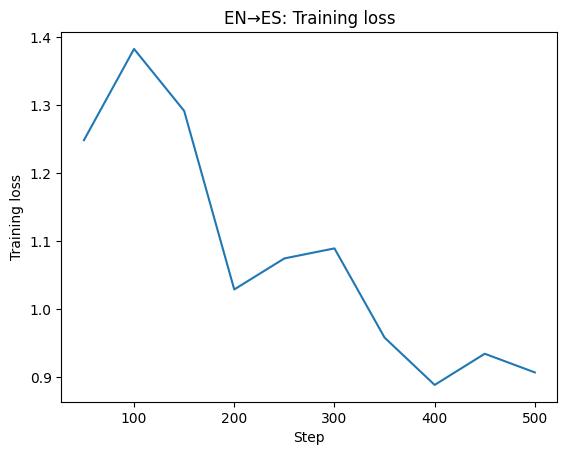

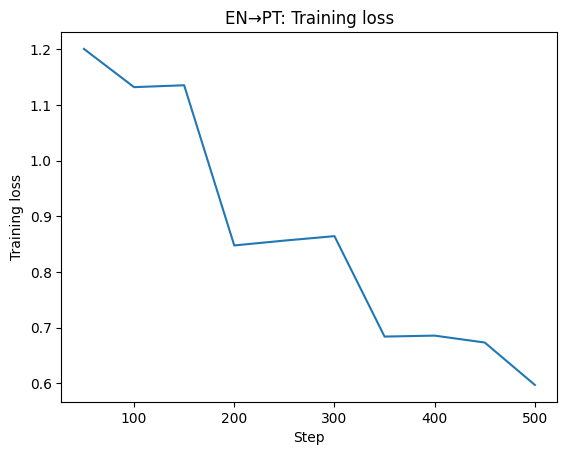

In [25]:
def plot_loss(trainer, title):
    loss_points = [(e["step"], e["loss"]) for e in getattr(trainer.state, "log_history", []) if "loss" in e]
    if not loss_points:
        print(f"{title}: no loss logs found (set logging_steps > 0).")
        return
    steps, losses = zip(*loss_points)
    plt.figure()
    plt.plot(steps, losses)
    plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title(title); plt.show()

plot_loss(trainer_es, "EN→ES: Training loss")
plot_loss(trainer_pt, "EN→PT: Training loss")


In [27]:
def translate_es(text, max_new_tokens=128, num_beams=5, use_glossary=True):
    q = apply_glossary(text, "es") if use_glossary else text
    enc = tok_es([q], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_es.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens,
                              no_repeat_ngram_size=3, early_stopping=True)
    return tok_es.batch_decode(out, skip_special_tokens=True)[0]

def translate_pt(text, max_new_tokens=128, num_beams=5, use_glossary=True):
    q = apply_glossary(text, "pt") if use_glossary else text
    enc = tok_pt([q], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_pt.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens,
                              no_repeat_ngram_size=3, early_stopping=True)
    return tok_pt.batch_decode(out, skip_special_tokens=True)[0]


print(translate_es("this is the systamatic review of a machine translation system that can keep certain equations like log(1+2)=sin(theta) ."
"."))
print(translate_pt("Hybrid and neural machine translation model for scientific research papers."))

Esta es la revisión sistamática de un sistema de traducción automática que puede mantener ciertas ecuaciones como log(1+2)=sin(theta) ..
Modelo de tradução automática híbrida e neural para trabalhos de pesquisa científica.
